In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from mpl_toolkits.mplot3d import Axes3D

Итерация 0: x=[0.000000, 0.600000], f=1.800000
Итерация 1: x=[-0.120000, 0.300000], f=0.421200
Итерация 2: x=[-0.084000, 0.174000], f=0.149364
Итерация 3: x=[-0.051600, 0.103800], f=0.053748
Итерация 4: x=[-0.031080, 0.062220], f=0.019349
Итерация 5: x=[-0.018660, 0.037326], f=0.006966
Итерация 6: x=[-0.011197, 0.022395], f=0.002508
Итерация 7: x=[-0.006718, 0.013437], f=0.000903
Итерация 8: x=[-0.004031, 0.008062], f=0.000325
Итерация 9: x=[-0.002419, 0.004837], f=0.000117
Итерация 10: x=[-0.001451, 0.002902], f=0.000042
Итерация 11: x=[-0.000871, 0.001741], f=0.000015
Итерация 12: x=[-0.000522, 0.001045], f=0.000005
Итерация 13: x=[-0.000313, 0.000627], f=0.000002
Итерация 14: x=[-0.000188, 0.000376], f=0.000001
Итерация 15: x=[-0.000113, 0.000226], f=0.000000
Итерация 16: x=[-0.000068, 0.000135], f=0.000000
Итерация 17: x=[-0.000041, 0.000081], f=0.000000
Итерация 18: x=[-0.000024, 0.000049], f=0.000000
Итерация 19: x=[-0.000015, 0.000029], f=0.000000
Итерация 20: x=[-0.000009, 0.00

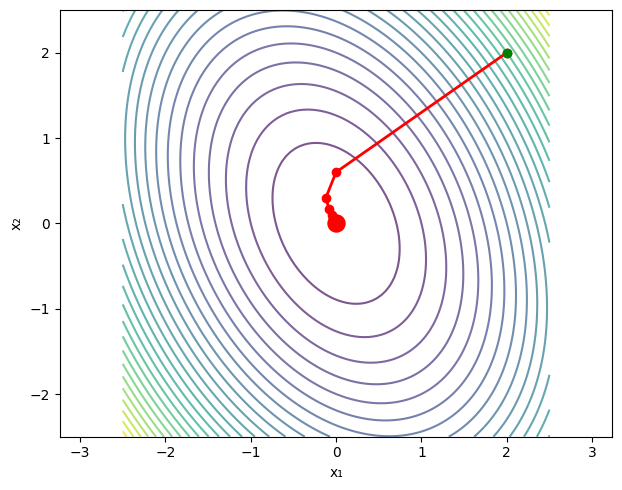


Приближение: x = (-0.000000, 0.000000), f = 0.00000000
Точный минимум: x = (0.0, 0.0), f = 0.0
Погрешность = 1.98e-07
Итераций: 30


In [33]:
def f(x):
    return 8*x[0]**2 + 5*x[1]**2 + 4*x[0]*x[1]
def grad_f(x):
    return np.array([16*x[0] + 4*x[1], 4*x[0] + 10*x[1]])
def gradient_descent(x0, alpha=0.05, eps=1e-6, max_iter=100):
    x = x0.copy()
    x_iter = [x.copy()]
    
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < eps:
            print(f"Остановка на итерации {i}: ||grad|| = {np.linalg.norm(g):.2e}")
            break
        
        x = x - alpha * g
        x_iter.append(x.copy())
        print(f"Итерация {i}: x=[{x[0]:.6f}, {x[1]:.6f}], f={f(x):.6f}")
    
    return np.array(x_iter), i+1

x0 = np.array([2.0, 2.0])
alpha = 0.05
eps = 1e-6
x_iter, iterations = gradient_descent(x0, alpha, eps, max_iter=30)

x_exact = np.array([0.0, 0.0])
y_exact = f(x_exact)

x1_plot = np.linspace(-2.5, 2.5, 100)
x2_plot = np.linspace(-2.5, 2.5, 100)
X1, X2 = np.meshgrid(x1_plot, x2_plot)
Z = 8*X1**2 + 5*X2**2 + 4*X1*X2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contour(X1, X2, Z, levels=30, cmap='viridis', alpha=0.7)
plt.plot(x_iter[:, 0], x_iter[:, 1], 'ro-', linewidth=2, markersize=6)
plt.plot(x_iter[0, 0], x_iter[0, 1], 'go')
plt.plot(x_iter[-1, 0], x_iter[-1, 1], 'rs')
plt.scatter(0, 0, color='red', s=150)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.axis('equal')

plt.tight_layout()
plt.show()

print(f"\nПриближение: x = ({x_iter[-1][0]:.6f}, {x_iter[-1][1]:.6f}), f = {f(x_iter[-1]):.8f}")
print(f"Точный минимум: x = ({x_exact[0]}, {x_exact[1]}), f = {y_exact}")
print(f"Погрешность = {np.linalg.norm(x_iter[-1] - x_exact):.2e}")
print(f"Итераций: {iterations}")

Итерация 0: x=[-0.249057, 0.425660], f=0.978113, α=0.056226
Итерация 1: x=[0.028768, 0.028768], f=0.014069, α=0.121732
Итерация 2: x=[-0.003582, 0.006123], f=0.000202, α=0.056226
Итерация 3: x=[0.000414, 0.000414], f=0.000003, α=0.121732
Итерация 4: x=[-0.000052, 0.000088], f=0.000000, α=0.056226
Итерация 5: x=[0.000006, 0.000006], f=0.000000, α=0.121732
Итерация 6: x=[-0.000001, 0.000001], f=0.000000, α=0.056226
Итерация 7: x=[0.000000, 0.000000], f=0.000000, α=0.121732
Итерация 8: x=[-0.000000, 0.000000], f=0.000000, α=0.056226
Остановка на итерации 9: ||grad|| = 1.70e-07


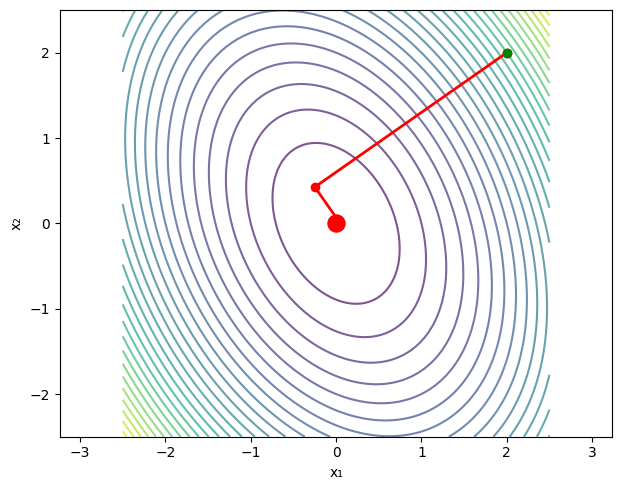

Точный минимум: x = (0.0, 0.0), f = 0.0
Погрешность = 2.11e-08
Итераций: 10


In [37]:
def f(x):
    return 8*x[0]**2 + 5*x[1]**2 + 4*x[0]*x[1]
def grad_f(x):
    return np.array([16*x[0] + 4*x[1], 4*x[0] + 10*x[1]])
def hessian_f():
    return np.array([[16, 4], [4, 10]])

def steepest_descent(x0, eps=1e-6, max_iter=30):
    x = x0.copy()
    x_iter = [x.copy()]
    H = hessian_f()
    
    for i in range(max_iter):
        g = grad_f(x)
        grad_norm = np.linalg.norm(g)
        
        if grad_norm < eps:
            print(f"Остановка на итерации {i}: ||grad|| = {grad_norm:.2e}")
            break
        
        alpha = np.dot(g, g) / np.dot(g, np.dot(H, g))
        
        x = x - alpha * g
        x_iter.append(x.copy())
        
        print(f"Итерация {i}: x=[{x[0]:.6f}, {x[1]:.6f}], f={f(x):.6f}, α={alpha:.6f}")
    
    return np.array(x_iter), i+1

x0 = np.array([2.0, 2.0])
eps = 1e-6
x_iter, iterations = steepest_descent(x0, eps, max_iter=30)

x_exact = np.array([0.0, 0.0])
y_exact = f(x_exact)

x1_plot = np.linspace(-2.5, 2.5, 100)
x2_plot = np.linspace(-2.5, 2.5, 100)
X1, X2 = np.meshgrid(x1_plot, x2_plot)
Z = 8*X1**2 + 5*X2**2 + 4*X1*X2

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contour(X1, X2, Z, levels=30, cmap='viridis', alpha=0.7)
plt.plot(x_iter[:, 0], x_iter[:, 1], 'ro-', linewidth=2, markersize=6)
plt.plot(x_iter[0, 0], x_iter[0, 1], 'go')
plt.plot(x_iter[-1, 0], x_iter[-1, 1], 'rs')
plt.scatter(0, 0, color='red', s=150)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Точный минимум: x = ({x_exact[0]}, {x_exact[1]}), f = {y_exact}")
print(f"Погрешность = {np.linalg.norm(x_iter[-1] - x_exact):.2e}")
print(f"Итераций: {iterations}")

Итерация 0: x=[-0.249057, 0.425660], f=0.978113, α=0.056226, β=0.006644
Итерация 1: x=[-0.000000, -0.000000], f=0.000000, α=0.123509, β=0.000000
Остановка на итерации 2: ||grad|| = 2.23e-15


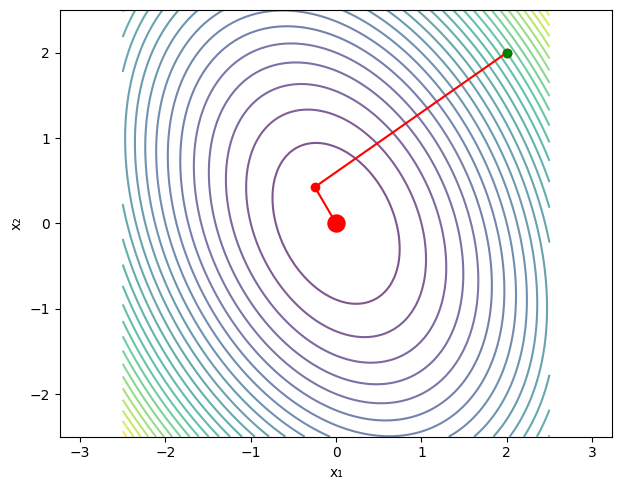


Приближение: x = (-0.000000, -0.000000), f = 0.00000000
Точный минимум: x = (0.0, 0.0), f = 0.0
Погрешность = 1.24e-16
Итераций: 3


In [39]:
def f(x):
    return 8*x[0]**2 + 5*x[1]**2 + 4*x[0]*x[1]
def grad_f(x):
    return np.array([16*x[0] + 4*x[1], 4*x[0] + 10*x[1]])
def hessian_f():
    return np.array([[16, 4], [4, 10]])

def conjugate_gradient(x0, eps=1e-6, max_iter=30):
    x = x0.copy()
    x_iter = [x.copy()]
    H = hessian_f()
    
    g = grad_f(x)
    d = -g
    
    for i in range(max_iter):
        grad_norm = np.linalg.norm(g)
        
        if grad_norm < eps:
            print(f"Остановка на итерации {i}: ||grad|| = {grad_norm:.2e}")
            break
        
        alpha = -np.dot(g, d) / np.dot(d, np.dot(H, d))
        
        x_new = x + alpha * d
        g_new = grad_f(x_new)
        
        beta = np.dot(g_new, g_new) / np.dot(g, g)
        
        d = -g_new + beta * d
        
        x_iter.append(x_new.copy())
        
        print(f"Итерация {i}: x=[{x_new[0]:.6f}, {x_new[1]:.6f}], f={f(x_new):.6f}, α={alpha:.6f}, β={beta:.6f}")
        
        x, g = x_new, g_new
    
    return np.array(x_iter), i+1

x0 = np.array([2.0, 2.0])
eps = 1e-6
x_iter, iterations = conjugate_gradient(x0, eps, max_iter=30)

x_exact = np.array([0.0, 0.0])
y_exact = f(x_exact)

x1_plot = np.linspace(-2.5, 2.5, 100)
x2_plot = np.linspace(-2.5, 2.5, 100)
X1, X2 = np.meshgrid(x1_plot, x2_plot)
Z = 8*X1**2 + 5*X2**2 + 4*X1*X2

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contour(X1, X2, Z, levels=30, cmap='viridis', alpha=0.7)
plt.plot(x_iter[:, 0], x_iter[:, 1], 'ro-')
plt.plot(x_iter[0, 0], x_iter[0, 1], 'go')
plt.plot(x_iter[-1, 0], x_iter[-1, 1], 'rs')
plt.scatter(0, 0, color='red', s=150,)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Результаты
print(f"\nПриближение: x = ({x_iter[-1][0]:.6f}, {x_iter[-1][1]:.6f}), f = {f(x_iter[-1]):.8f}")
print(f"Точный минимум: x = ({x_exact[0]}, {x_exact[1]}), f = {y_exact}")
print(f"Погрешность = {np.linalg.norm(x_iter[-1] - x_exact):.2e}")
print(f"Итераций: {iterations}")

Итерация 0: x=[0.000000, 0.000000], f=0.000000
Остановка на итерации 1: ||grad|| = 4.78e-15


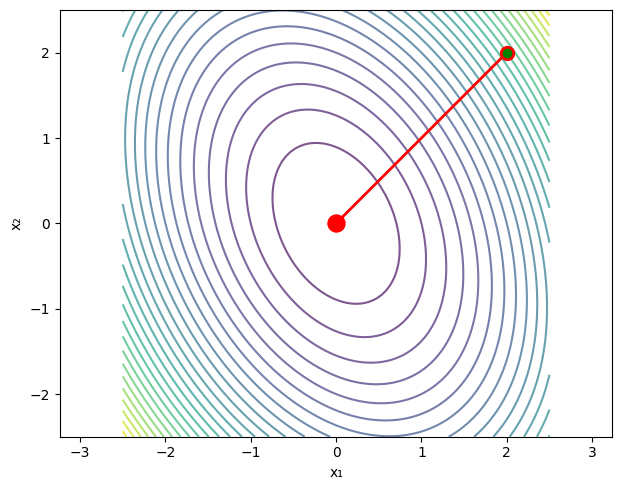

Начальная точка: x0 = (2.0, 2.0)
∇f(x0) = (40.0, 28.0)

Шаг Ньютона: Δx = -H⁻¹·∇f(x0)
Δx = [2. 2.]

Итерация 0 → 1: x1 = x0 - H⁻¹·∇f(x0)
x1 = (0.000000, 0.000000)

Приближение: x = (0.000000, 0.000000), f = 0.00000000
Точный минимум: x = (0.0, 0.0), f = 0.0
Погрешность = 4.44e-16
Итераций: 2


In [41]:
def f(x):
    return 8*x[0]**2 + 5*x[1]**2 + 4*x[0]*x[1]
def grad_f(x):
    return np.array([16*x[0] + 4*x[1], 4*x[0] + 10*x[1]])
def hessian_f():
    return np.array([[16, 4], [4, 10]])

def newton_method(x0, eps=1e-6, max_iter=10):
    x = x0.copy()
    x_iter = [x.copy()]
    H = hessian_f()
    H_inv = np.linalg.inv(H)
    
    for i in range(max_iter):
        g = grad_f(x)
        grad_norm = np.linalg.norm(g)
        
        if grad_norm < eps:
            print(f"Остановка на итерации {i}: ||grad|| = {grad_norm:.2e}")
            break
        
        x = x - np.dot(H_inv, g)
        x_iter.append(x.copy())
        
        print(f"Итерация {i}: x=[{x[0]:.6f}, {x[1]:.6f}], f={f(x):.6f}")
    
    return np.array(x_iter), i+1

x0 = np.array([2.0, 2.0])
eps = 1e-6

x_iter, iterations = newton_method(x0, eps, max_iter=5)

x_exact = np.array([0.0, 0.0])
y_exact = f(x_exact)

x1_plot = np.linspace(-2.5, 2.5, 100)
x2_plot = np.linspace(-2.5, 2.5, 100)
X1, X2 = np.meshgrid(x1_plot, x2_plot)
Z = 8*X1**2 + 5*X2**2 + 4*X1*X2

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contour(X1, X2, Z, levels=30, cmap='viridis', alpha=0.7)
plt.plot(x_iter[:, 0], x_iter[:, 1], 'ro-', linewidth=2, markersize=10)
plt.plot(x_iter[0, 0], x_iter[0, 1], 'go')
plt.plot(x_iter[-1, 0], x_iter[-1, 1], 'rs')
plt.scatter(0, 0, color='red', s=150)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.axis('equal')
plt.tight_layout()
plt.show()

H = hessian_f()
H_inv = np.linalg.inv(H)

print(f"Начальная точка: x0 = ({x0[0]}, {x0[1]})")
print(f"∇f(x0) = ({grad_f(x0)[0]}, {grad_f(x0)[1]})")
print(f"\nШаг Ньютона: Δx = -H⁻¹·∇f(x0)")
print(f"Δx = {np.dot(H_inv, grad_f(x0))}")
print(f"\nИтерация 0 → 1: x1 = x0 - H⁻¹·∇f(x0)")
print(f"x1 = ({x_iter[1][0]:.6f}, {x_iter[1][1]:.6f})")
print(f"\nПриближение: x = ({x_iter[-1][0]:.6f}, {x_iter[-1][1]:.6f}), f = {f(x_iter[-1]):.8f}")
print(f"Точный минимум: x = ({x_exact[0]}, {x_exact[1]}), f = {y_exact}")
print(f"Погрешность = {np.linalg.norm(x_iter[-1] - x_exact):.2e}")
print(f"Итераций: {iterations}")


a        Метод                Итераций     Конечная точка            f(x*)       
1        Градиентный спуск    60           (0.0000, 0.0000):<9 1.88e-11    
1        Наискорейший спуск   1            (0.0000, 0.0000):<9 0.00e+00    
1        Сопряжённые градиенты 1            (0.0000, 0.0000):<9 0.00e+00    


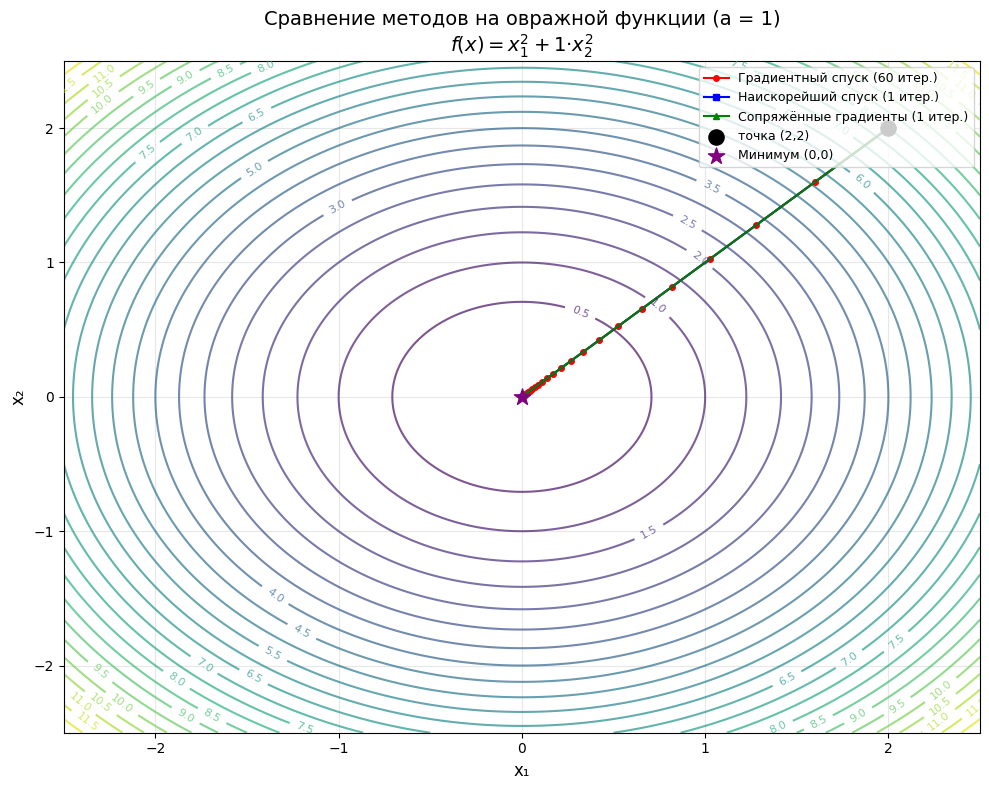

C:\Users\alalt\AppData\Local\Temp\ipykernel_12700\2467087515.py:10: RuntimeWarning: overflow encountered in scalar multiply
  return np.array([2*x[0], 2*a*x[1]])
C:\Users\alalt\AppData\Local\Temp\ipykernel_12700\2467087515.py:20: RuntimeWarning: invalid value encountered in subtract
  x = x - alpha * g


100      Градиентный спуск    1000         (0.0000, nan):<9 nan         
100      Наискорейший спуск   7            (0.0000, -0.0000):<9 3.27e-12    
100      Сопряжённые градиенты 2            (0.0000, 0.0000):<9 1.10e-26    


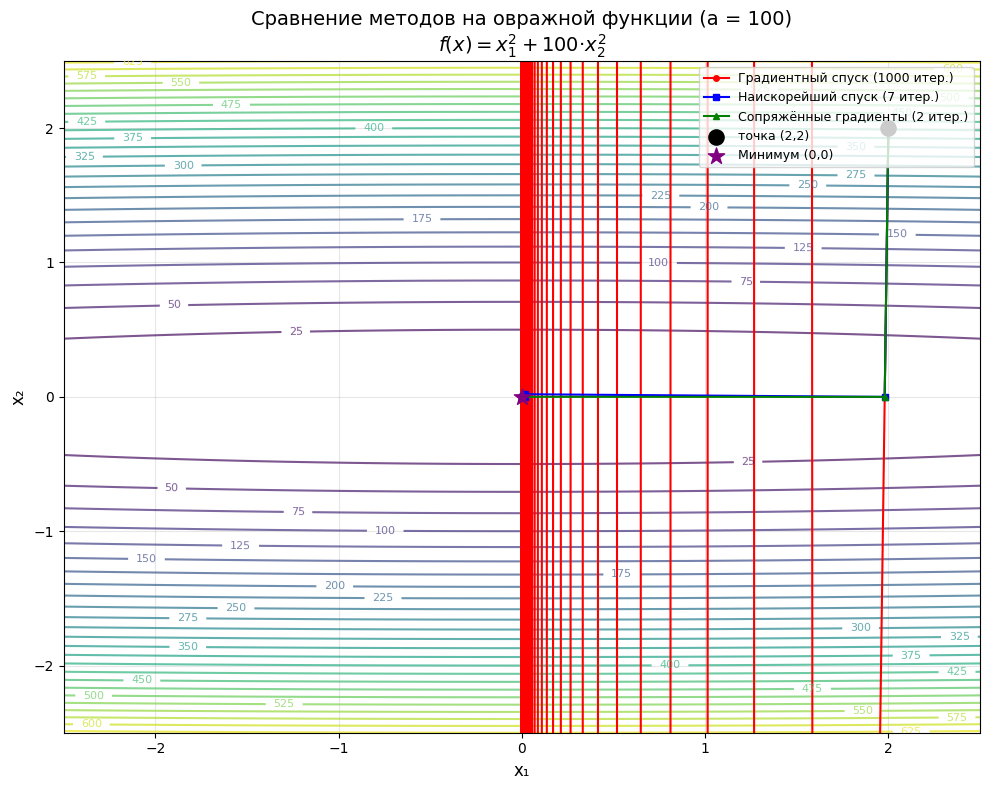

500      Градиентный спуск    1000         (0.0000, nan):<9 nan         
500      Наискорейший спуск   7            (0.0000, -0.0000):<9 2.46e-16    
500      Сопряжённые градиенты 2            (-0.0000, -0.0000):<9 9.93e-24    


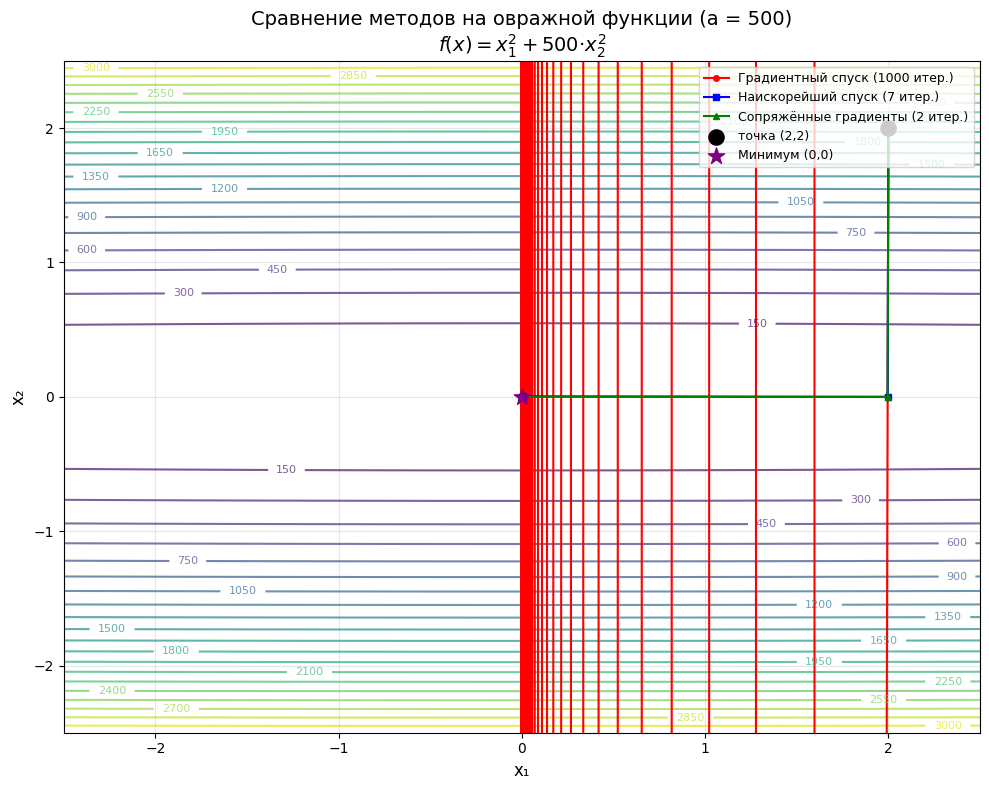

1000     Градиентный спуск    1000         (0.0000, nan):<9 nan         
1000     Наискорейший спуск   5            (0.0000, -0.0000):<9 3.94e-12    
1000     Сопряжённые градиенты 2            (0.0000, 0.0000):<9 1.12e-22    


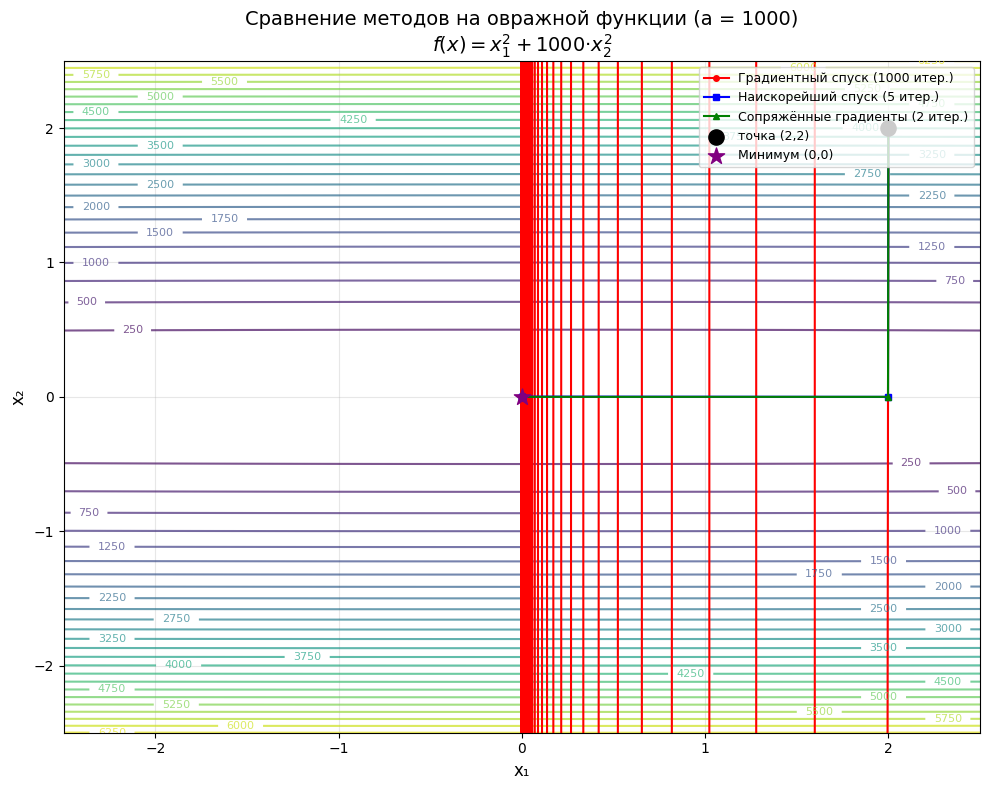

In [50]:
a_values = [1, 100, 500, 1000]
eps = 1e-5
x0 = np.array([2.0, 2.0])  

def f(x, a):
    """f(x) = x1² + a·x2²"""
    return x[0]**2 + a * x[1]**2

def grad(x, a):
    return np.array([2*x[0], 2*a*x[1]])

def gradient_descent(x0, a, alpha=0.1, eps=1e-5, max_iter=1000):
    x = x0.copy()
    history = [x.copy()]
    
    for _ in range(max_iter):
        g = grad(x, a)
        if np.linalg.norm(g) < eps:
            break
        x = x - alpha * g
        history.append(x.copy())
    
    return np.array(history)

def steepest_descent(x0, a, eps=1e-5, max_iter=1000):
    x = x0.copy()
    history = [x.copy()]
    
    for _ in range(max_iter):
        g = grad(x, a)
        if np.linalg.norm(g) < eps:
            break
       
        H = np.array([[2, 0], [0, 2*a]])
        alpha = (g @ g) / (g @ (H @ g))
        
        x = x - alpha * g
        history.append(x.copy())
    
    return np.array(history)

def conjugate_gradients(x0, a, eps=1e-5, max_iter=1000):
    x = x0.copy()
    g = grad(x, a)
    d = -g
    history = [x.copy()]
    
    for _ in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        
        H = np.array([[2, 0], [0, 2*a]])
        alpha = - (g @ d) / (d @ (H @ d))
        x_new = x + alpha * d
        g_new = grad(x_new, a)
        beta = (g_new @ g_new) / (g @ g)
        d = -g_new + beta * d
        x, g = x_new, g_new
        history.append(x.copy())
    
    return np.array(history)

print(f"{'a':<8} {'Метод':<20} {'Итераций':<12} {'Конечная точка':<25} {'f(x*)':<12}")


for a in a_values:
    gd_path = gradient_descent(x0, a, alpha=0.1, eps=eps)
    sd_path = steepest_descent(x0, a, eps=eps)
    cg_path = conjugate_gradients(x0, a, eps=eps)
    
    print(f"{a:<8} {'Градиентный спуск':<20} {len(gd_path)-1:<12} ({gd_path[-1][0]:.4f}, {gd_path[-1][1]:.4f}){':<9'} {f(gd_path[-1], a):<12.2e}")
    print(f"{a:<8} {'Наискорейший спуск':<20} {len(sd_path)-1:<12} ({sd_path[-1][0]:.4f}, {sd_path[-1][1]:.4f}){':<9'} {f(sd_path[-1], a):<12.2e}")
    print(f"{a:<8} {'Сопряжённые градиенты':<20} {len(cg_path)-1:<12} ({cg_path[-1][0]:.4f}, {cg_path[-1][1]:.4f}){':<9'} {f(cg_path[-1], a):<12.2e}")

    
    x1_vals = np.linspace(-2.5, 2.5, 400)
    x2_vals = np.linspace(-2.5, 2.5, 400)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    Z = f([X1, X2], a)
    
    plt.figure(figsize=(10, 8))
    contour = plt.contour(X1, X2, Z, levels=30, cmap='viridis', alpha=0.7)
    plt.clabel(contour, inline=True, fontsize=8)
    
    plt.plot(gd_path[:, 0], gd_path[:, 1], 'o-', linewidth=1.5, markersize=4, 
             label=f'Градиентный спуск ({len(gd_path)-1} итер.)', color='red')
    plt.plot(sd_path[:, 0], sd_path[:, 1], 's-', linewidth=1.5, markersize=4, 
             label=f'Наискорейший спуск ({len(sd_path)-1} итер.)', color='blue')
    plt.plot(cg_path[:, 0], cg_path[:, 1], '^-', linewidth=1.5, markersize=4, 
             label=f'Сопряжённые градиенты ({len(cg_path)-1} итер.)', color='green')
    
    plt.scatter(x0[0], x0[1], color='black', s=120, marker='o', label='точка (2,2)', zorder=5)
    plt.scatter(0, 0, color='purple', s=150, marker='*', label='Минимум (0,0)', zorder=5)
    
    plt.xlabel('x₁', fontsize=12)
    plt.ylabel('x₂', fontsize=12)
    plt.title(f'Сравнение методов на овражной функции (a = {a})\n$f(x) = x_1^2 + {a}·x_2^2$', fontsize=14)
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True, alpha=0.3)
    #plt.axis('equal')
    plt.xlim(-2.5, 2.5)
    plt.ylim(-2.5, 2.5)
    plt.tight_layout()
    plt.savefig(f'ravine_a_{a}.png', dpi=150, bbox_inches='tight')
    plt.show()